# Modelado Supervisado - Predicción de Enfermedad Cardiovascular

En este notebook se desarrollará el proceso de modelado supervisado utilizando el dataset completo generado después del Feature Engineering.

El objetivo principal es entrenar y comparar diferentes modelos de clasificación para predecir la presencia de enfermedad cardiovascular (`cardio`). Para ello, se evaluarán varios algoritmos mediante métricas como accuracy, precision, recall, F1-score y ROC-AUC.

In [23]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y escalado
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Configuración visual
sns.set(style="whitegrid")

In [24]:
# Cargar dataset completo después del Feature Engineering
df = pd.read_csv("cardio_features_full.csv")

df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score,pulse_pressure,mean_arterial_pressure,age_pressure
0,50,2,168,62.0,110,80,1,1,0,0,...,normal,0,hipertension_etapa_1,1,0,0,1,30,90.000000,5500
1,55,1,156,85.0,140,90,3,1,0,0,...,obesidad,1,hipertension_etapa_2,1,1,0,3,50,106.666667,7700
2,51,1,165,64.0,130,70,3,1,0,0,...,normal,0,hipertension_etapa_1,1,1,1,3,60,90.000000,6630
3,48,2,169,82.0,150,100,1,1,0,0,...,sobrepeso,0,hipertension_etapa_2,1,0,0,1,50,116.666667,7200
4,47,1,156,56.0,100,60,1,1,0,0,...,normal,0,normal,0,0,1,1,40,73.333333,4700


In [25]:
# Revisar dimensiones
df.shape

(65307, 23)

In [26]:
# Revisar columnas
df.columns

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi',
       'bmi_category', 'obesity', 'bp_category', 'hypertension',
       'metabolic_risk', 'lifestyle_risk', 'risk_score', 'pulse_pressure',
       'mean_arterial_pressure', 'age_pressure'],
      dtype='str')

In [27]:
# Variable objetivo
y = df["cardio"]

# Variables predictoras
X = df.drop(columns=["cardio"])

In [28]:
# Convertir variables categóricas a dummies 
X = pd.get_dummies(X, drop_first=True)

In [29]:
# Separación entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (52245, 26)
X_test: (13062, 26)
y_train: (52245,)
y_test: (13062,)


In [30]:
# Escalado de variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluación de modelos

### Dataset completo

In [31]:
# Modelos base para comparación inicial

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [32]:
resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}")
    
    modelo.fit(X_train_scaled, y_train)
    
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

resultados_df = pd.DataFrame(resultados)

# Mostrar resultados ordenados por ROC-AUC
resultados_df.sort_values(by="ROC-AUC", ascending=False)

Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.727224,0.750820,0.691285,0.719824,0.792053
3,SVM,0.727147,0.760525,0.673916,0.714606,0.785017
5,Naive Bayes,0.708391,0.728025,0.677994,0.702119,0.768212
2,Random Forest,0.685730,0.692002,0.684791,0.688378,0.740905
4,KNN,0.684964,0.694203,0.676484,0.685229,0.733456
1,Decision Tree,0.612311,0.619567,0.609274,0.614377,0.611948


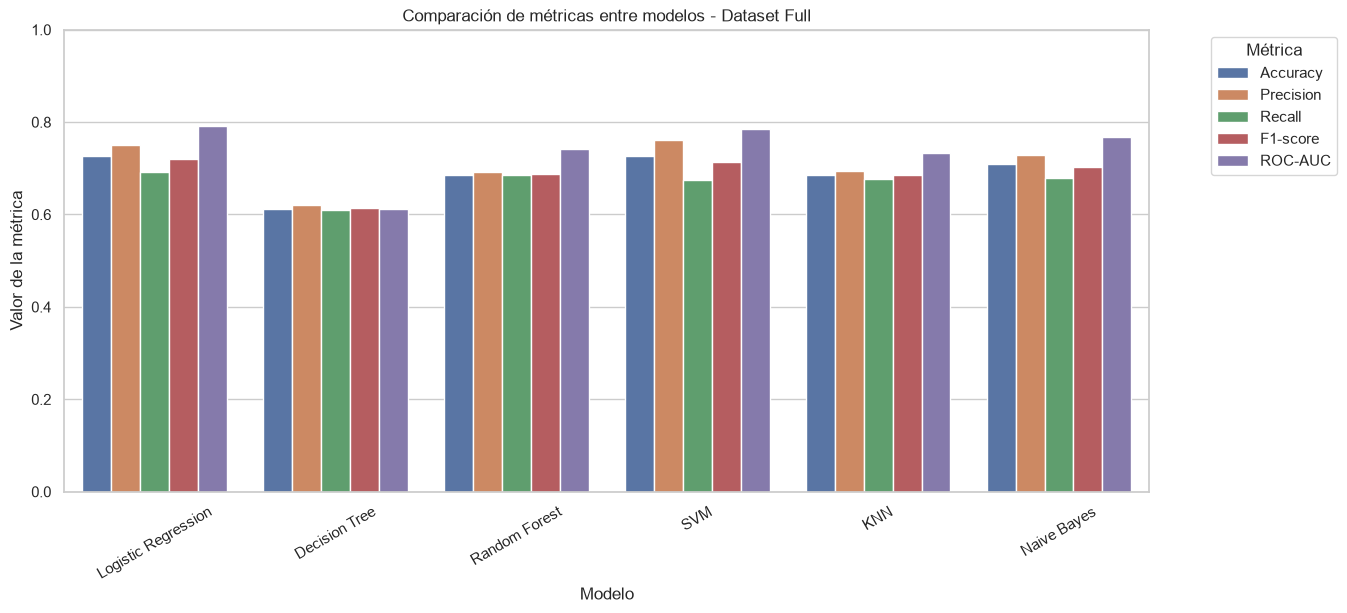

In [33]:
# Convertir resultados a formato largo para graficar
resultados_melted = resultados_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=resultados_melted,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación de métricas entre modelos - Dataset Full")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

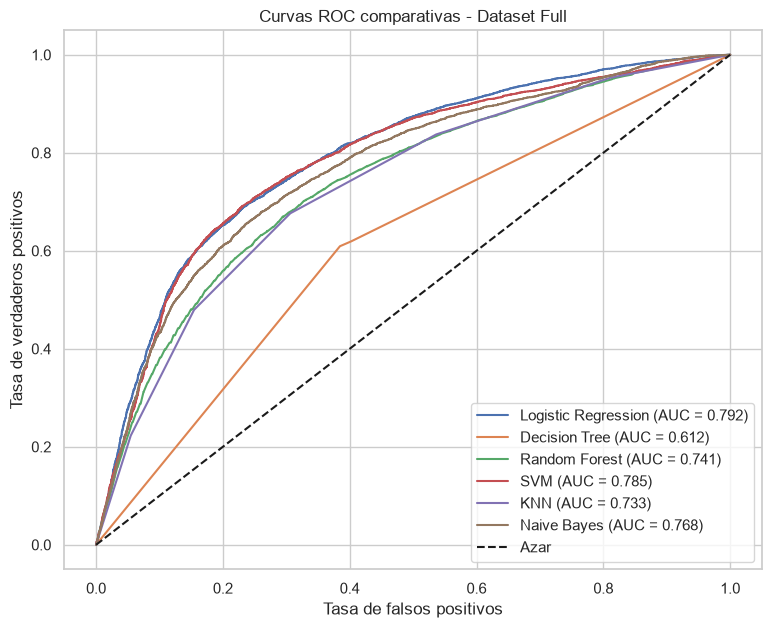

In [34]:
plt.figure(figsize=(9, 7))

for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Azar")

plt.title("Curvas ROC comparativas - Dataset Full")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
def evaluar_dataset(df_modelo, nombre_dataset):
    print("=" * 80)
    print(f"EVALUACIÓN DE MODELOS - {nombre_dataset}")
    print("=" * 80)
    
    # Separar variable objetivo y predictoras
    y = df_modelo["cardio"]
    X = df_modelo.drop(columns=["cardio"])
    
    # Convertir variables categóricas a dummies si existen
    X = pd.get_dummies(X, drop_first=True)
    
    # División entrenamiento/prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Modelos base
    modelos = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "KNN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB()
    }
    
    resultados = []
    
    # Entrenamiento y métricas
    for nombre, modelo in modelos.items():
        print(f"Entrenando modelo: {nombre}")
        
        modelo.fit(X_train_scaled, y_train)
        
        y_pred = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        
        resultados.append({
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba)
        })
    
    resultados_df = pd.DataFrame(resultados)
    resultados_df = resultados_df.sort_values(by="ROC-AUC", ascending=False)
    
    display(resultados_df)
    
    # Gráfica de barras comparativa
    resultados_melted = resultados_df.melt(
        id_vars="Modelo",
        value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
        var_name="Métrica",
        value_name="Valor"
    )
    
    plt.figure(figsize=(14, 6))
    
    sns.barplot(
        data=resultados_melted,
        x="Modelo",
        y="Valor",
        hue="Métrica"
    )
    
    plt.title(f"Comparación de métricas entre modelos - {nombre_dataset}")
    plt.xlabel("Modelo")
    plt.ylabel("Valor de la métrica")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)
    plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()
    
    # Curvas ROC comparativas
    plt.figure(figsize=(9, 7))
    
    for nombre, modelo in modelos.items():
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_score:.3f})")
    
    plt.plot([0, 1], [0, 1], "k--", label="Azar")
    
    plt.title(f"Curvas ROC comparativas - {nombre_dataset}")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return resultados_df

### Dataset reducido 1

In [36]:
# cargar datasets reducidos
df_reduced_v1 = pd.read_csv("cardio_features_reduced1.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V1
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.726688,0.749632,0.691889,0.719604,0.792185
3,SVM,0.728143,0.761677,0.674823,0.715624,0.785776
5,Naive Bayes,0.707931,0.721713,0.689775,0.705383,0.767310
2,Random Forest,0.685959,0.691152,0.687812,0.689478,0.736625
4,KNN,0.685883,0.692980,0.682827,0.687866,0.732977
1,Decision Tree,0.615220,0.622073,0.613805,0.617911,0.614562


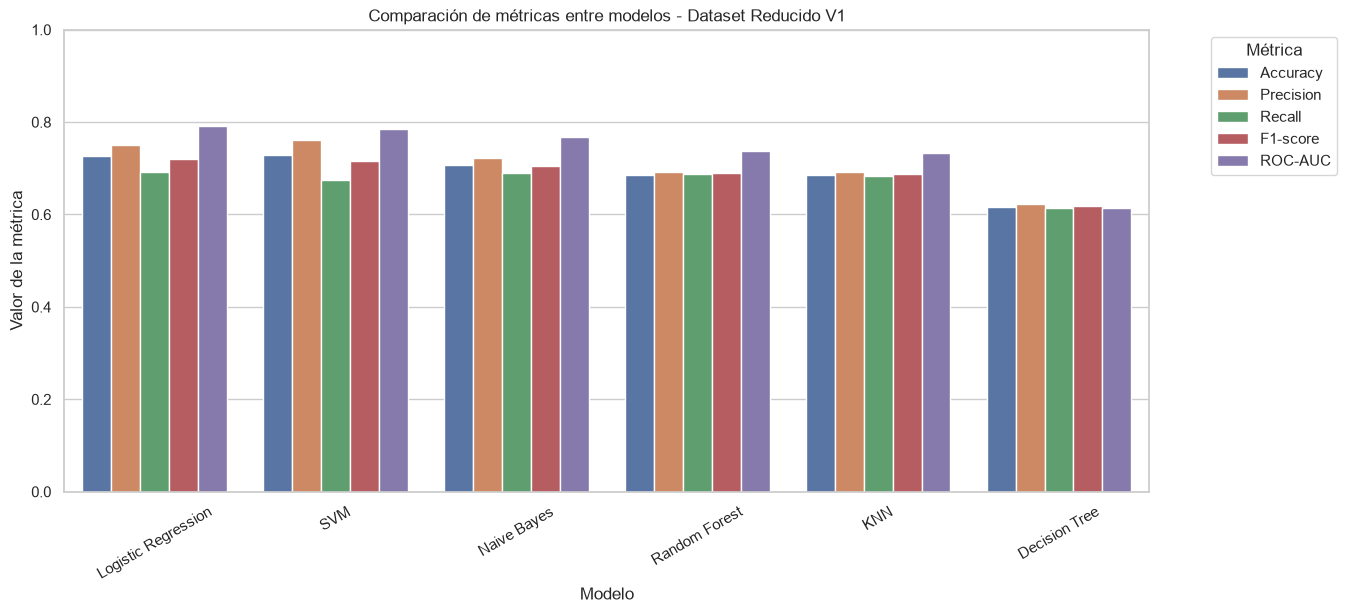

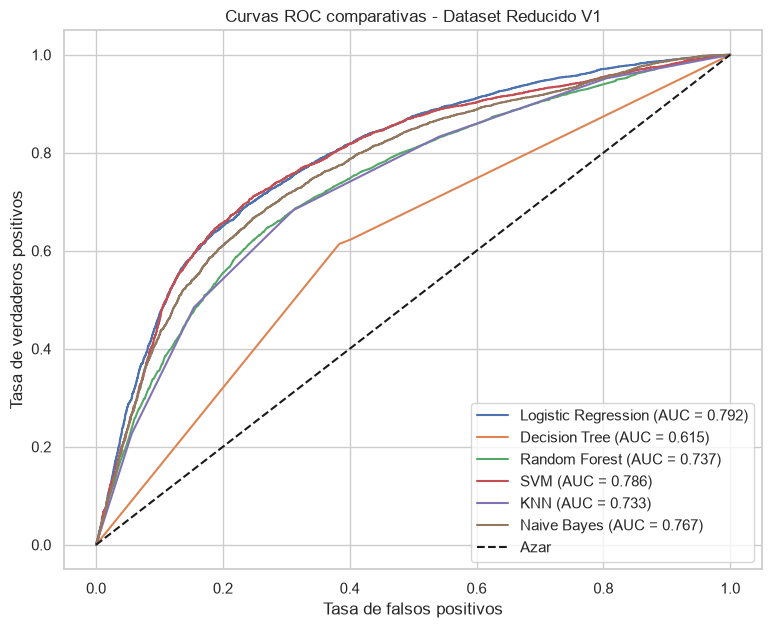

In [37]:
resultados_reduced_v1 = evaluar_dataset(
    df_reduced_v1,
    "Dataset Reducido V1"
)

### Dataset reducido 2

In [38]:
# cargar datasets reducidos
df_reduced_v2 = pd.read_csv("cardio_features_reduced2.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V2
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.724315,0.748682,0.686603,0.716300,0.790710
3,SVM,0.728219,0.763424,0.672104,0.714859,0.779886
5,Naive Bayes,0.708161,0.722196,0.689473,0.705455,0.765956
4,KNN,0.684964,0.691649,0.682978,0.687286,0.732119
2,Random Forest,0.660848,0.663045,0.672859,0.667916,0.714738
1,Decision Tree,0.621880,0.629664,0.616825,0.623178,0.622397


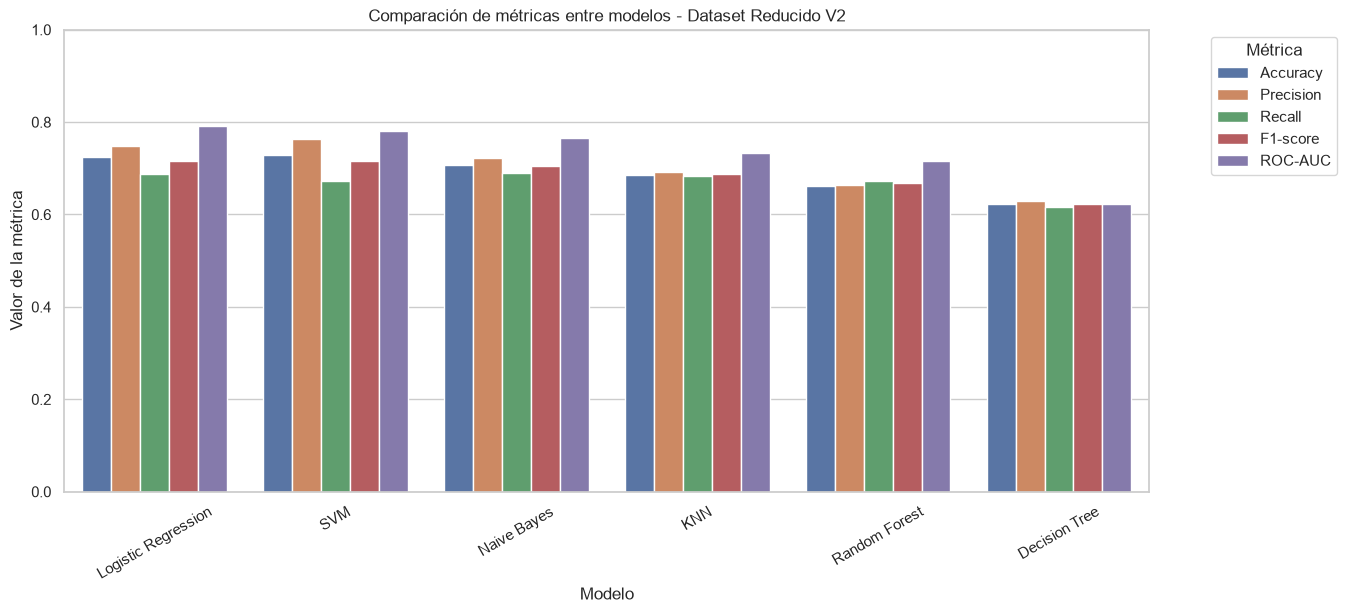

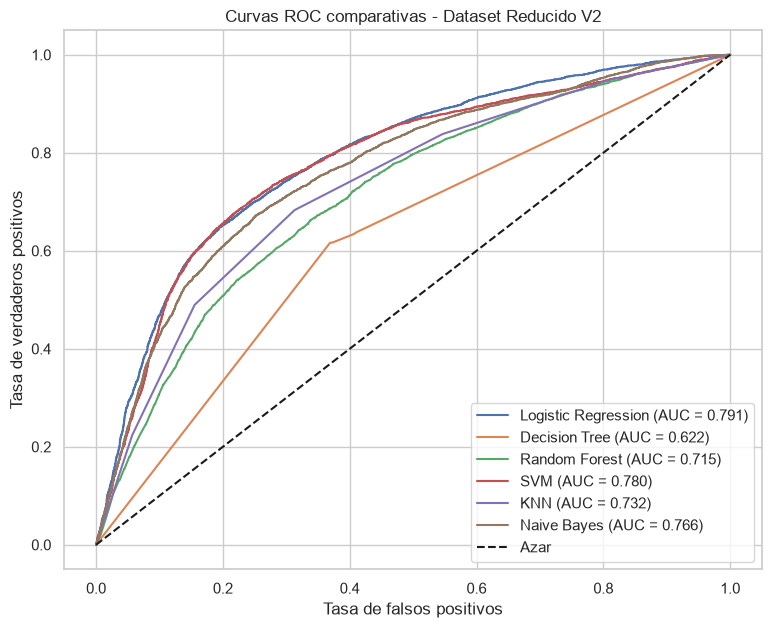

In [39]:
resultados_reduced_v2 = evaluar_dataset(
    df_reduced_v2,
    "Dataset Reducido V2"
)

### Dataset reducido 3

In [40]:
df_reduced_v3 = pd.read_csv("cardio_features_reduced3.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V3
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.723243,0.755612,0.671047,0.710823,0.789800
3,SVM,0.727683,0.759134,0.677843,0.716189,0.785801
5,Naive Bayes,0.690936,0.701560,0.679203,0.690200,0.756734
2,Random Forest,0.683816,0.689085,0.685546,0.687311,0.739509
4,KNN,0.683356,0.692189,0.675880,0.683937,0.731228
1,Decision Tree,0.606492,0.612214,0.610180,0.611195,0.605965


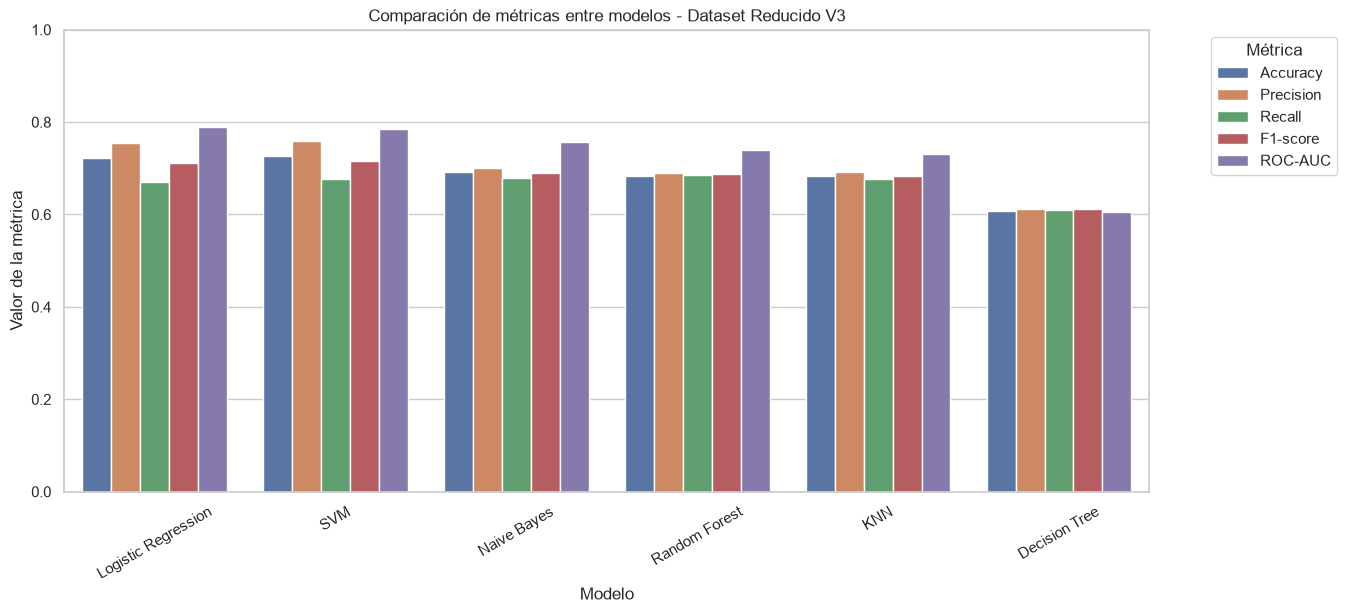

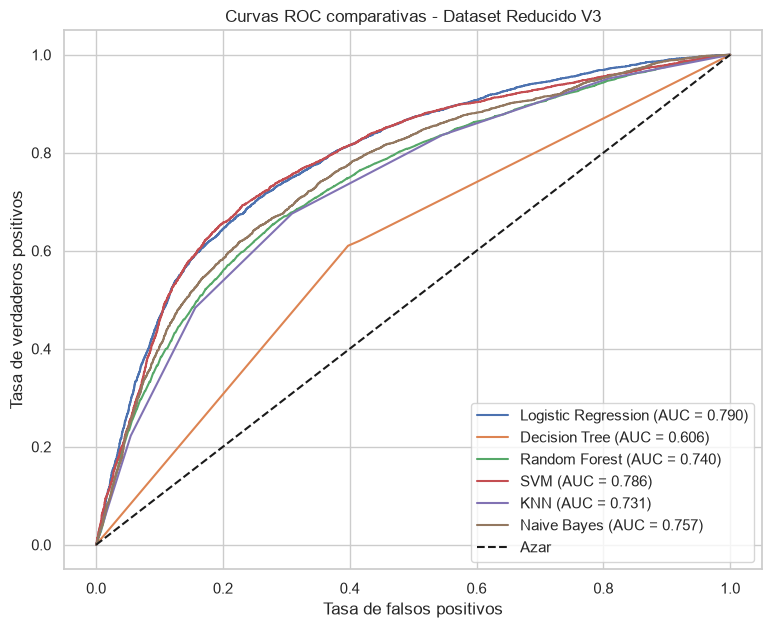

In [41]:
# evaluar dataset reducido 3
resultados_reduced_v3 = evaluar_dataset(
    df_reduced_v3,
    "Dataset Reducido V3"
)

### una prueba mas...

In [42]:
# Copia del dataset full o clean
df_exp = df.copy()

# Variables del ejemplo
df_exp["cholesterol_gluc_interaction"] = df_exp["cholesterol"] * df_exp["gluc"]

df_exp["health_index"] = (
    df_exp["active"] * 1
    - df_exp["smoke"] * 0.5
    - df_exp["alco"] * 0.5
)

# Si no existe pulse_pressure
if "pulse_pressure" not in df_exp.columns:
    df_exp["pulse_pressure"] = df_exp["ap_hi"] - df_exp["ap_lo"]

# Separar X / y
y = df_exp["cardio"]
X = df_exp.drop(columns=["cardio"])

# Dummies si tienes variables categóricas tipo bp_category, bmi_category
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1234,
    stratify=y
)

# Escalado solo para modelos que lo necesitan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Árbol como el ejemplo
dt_ejemplo = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=7,
    min_samples_leaf=3,
    random_state=42
)

dt_ejemplo.fit(X_train, y_train)

y_pred = dt_ejemplo.predict(X_test)
y_proba = dt_ejemplo.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.721810497948184
Precision: 0.7382593159775396
Recall: 0.6990091831802804
F1: 0.718098311817279
ROC-AUC: 0.7803637579521896
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      8051
           1       0.74      0.70      0.72      8276

    accuracy                           0.72     16327
   macro avg       0.72      0.72      0.72     16327
weighted avg       0.72      0.72      0.72     16327



EVALUACIÓN DE MODELOS - Dataset con nuevas variables
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.719721,0.752301,0.666516,0.706815,0.789297
3,SVM,0.728066,0.762353,0.673463,0.715156,0.786038
5,Naive Bayes,0.698438,0.714973,0.673614,0.693678,0.758072
2,Random Forest,0.690017,0.696817,0.687660,0.692208,0.742409
4,KNN,0.684887,0.694699,0.674974,0.684694,0.731476
1,Decision Tree,0.614607,0.621164,0.614409,0.617768,0.614496


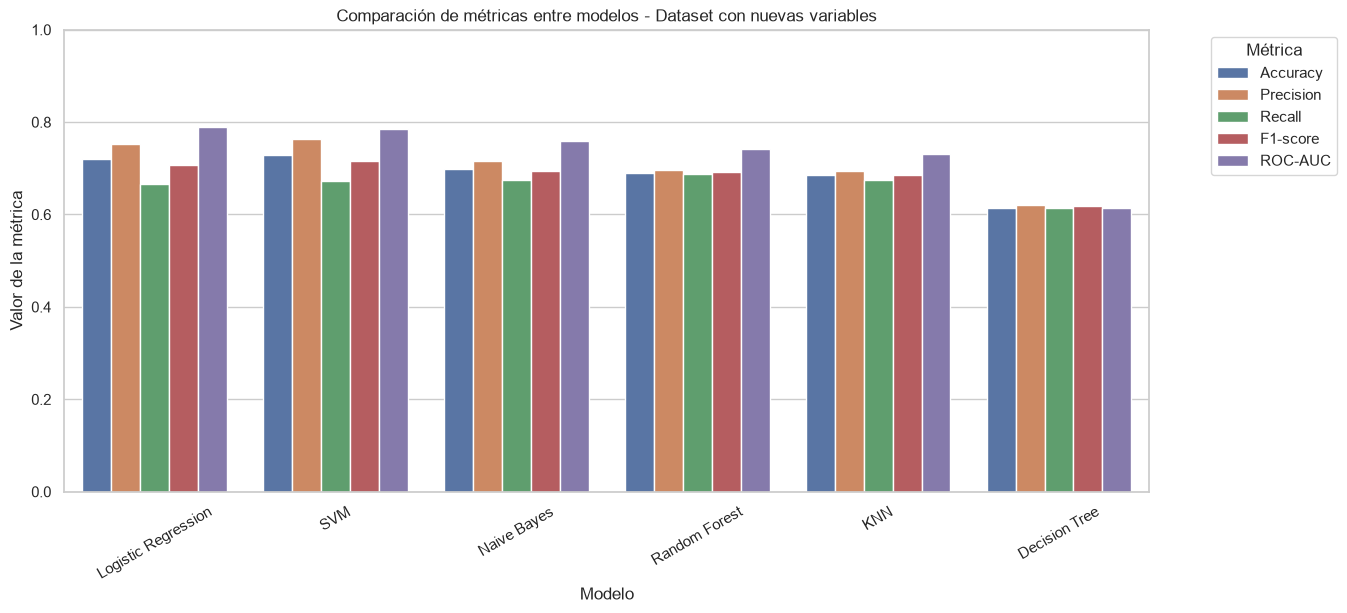

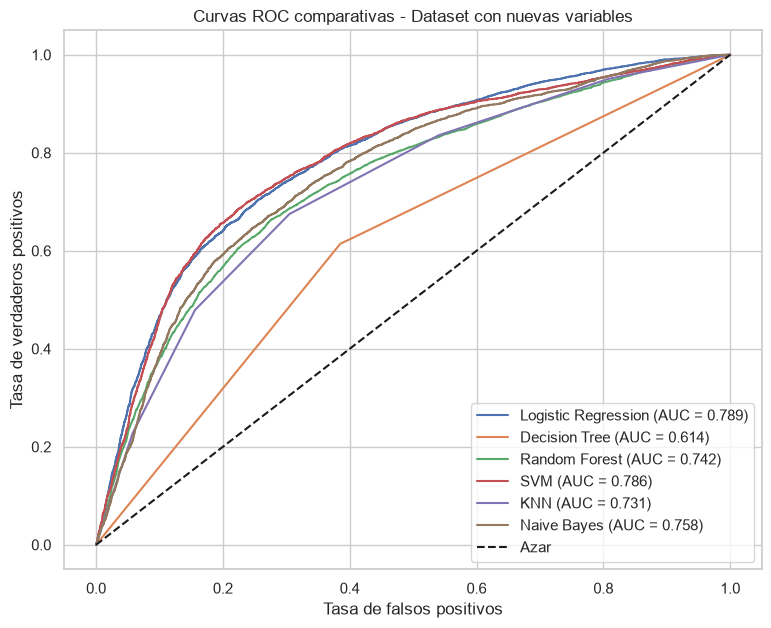

In [43]:
# evalua dataset v4
df_v4 = pd.read_csv("cardio_features_v4.csv")
resultados_exp = evaluar_dataset(
    df_v4,
    "Dataset con nuevas variables"
)

## Comparacion y optimizacion de modelos
modelos seleccionados:
- VFULL - Regresion logistica
- V3 - SVM
- V3 - Random forest     
Después de comparar los modelos base en las distintas versiones del dataset, se decidió optimizar tres combinaciones específicas: Logistic Regression con el dataset Full, SVM con el dataset Reducido V3 y Random Forest con el dataset Reducido V3. Esta decisión se tomó porque Logistic Regression obtuvo su mejor desempeño general en el dataset Full, especialmente en ROC-AUC y F1-score; SVM presentó una ligera mejora en todas sus métricas al utilizar la versión V3; y Random Forest alcanzó su mejor recall en V3, métrica relevante en un problema de salud, ya que permite identificar una mayor proporción de casos positivos. Por esta razón, la optimización no se realizará sobre un único dataset, sino sobre la mejor combinación modelo-dataset observada en la comparación inicial.


In [44]:
# ============================================================
# FUNCIÓN PARA PREPARAR DATASET
# ============================================================

def preparar_dataset(df_modelo):
    y = df_modelo["cardio"]
    X = df_modelo.drop(columns=["cardio"])

    # Convertir variables categóricas a dummies
    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [45]:
# ============================================================
# DATASETS SELECCIONADOS PARA OPTIMIZACIÓN
# ============================================================

df_full = pd.read_csv("cardio_features_full.csv")
df_v3 = pd.read_csv("cardio_features_reduced3.csv")

X_train_full, X_test_full, y_train_full, y_test_full = preparar_dataset(df_full)
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = preparar_dataset(df_v3)

In [46]:
# ============================================================
# FUNCIÓN DE EVALUACIÓN FINAL
# ============================================================

def evaluar_modelo_optimizado(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    }

    print("=" * 70)
    print(nombre_modelo)
    print("=" * 70)
    print("Accuracy:", resultados["Accuracy"])
    print("Precision:", resultados["Precision"])
    print("Recall:", resultados["Recall"])
    print("F1-score:", resultados["F1-score"])
    print("ROC-AUC:", resultados["ROC-AUC"])
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    return resultados

### Validación cruzada

In [47]:
# ============================================================
# VALIDACIÓN CRUZADA DE MODELOS CANDIDATOS
# ============================================================

from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Preparar X / y completos para validación cruzada
# ============================================================

# Dataset Full para Logistic Regression
y_full = df_full["cardio"]
X_full = df_full.drop(columns=["cardio"])
X_full = pd.get_dummies(X_full, drop_first=True)

# Dataset V3 para SVM y Random Forest
y_v3 = df_v3["cardio"]
X_v3 = df_v3.drop(columns=["cardio"])
X_v3 = pd.get_dummies(X_v3, drop_first=True)

# ============================================================
# Modelos candidatos
# ============================================================

modelo_lr_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

modelo_svm_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

modelo_rf_cv = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

modelos_cv = {
    "Logistic Regression - Full": (modelo_lr_cv, X_full, y_full),
    "SVM - V3": (modelo_svm_cv, X_v3, y_v3),
    "Random Forest - V3": (modelo_rf_cv, X_v3, y_v3)
}

# ============================================================
# Métricas de validación cruzada
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

resultados_cv = []

for nombre, (modelo, X_data, y_data) in modelos_cv.items():
    
    print(f"Ejecutando validación cruzada para: {nombre}")
    
    cv_result = cross_validate(
        estimator=modelo,
        X=X_data,
        y=y_data,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy promedio": cv_result["test_accuracy"].mean(),
        "Accuracy std": cv_result["test_accuracy"].std(),
        "Precision promedio": cv_result["test_precision"].mean(),
        "Recall promedio": cv_result["test_recall"].mean(),
        "F1 promedio": cv_result["test_f1"].mean(),
        "ROC-AUC promedio": cv_result["test_roc_auc"].mean()
    })

resultados_cv_df = pd.DataFrame(resultados_cv)

resultados_cv_df = resultados_cv_df.sort_values(
    by="Accuracy promedio",
    ascending=False
)

resultados_cv_df

Ejecutando validación cruzada para: Logistic Regression - Full
Ejecutando validación cruzada para: SVM - V3
Ejecutando validación cruzada para: Random Forest - V3


,Modelo,Accuracy promedio,Accuracy std,Precision promedio,Recall promedio,F1 promedio,ROC-AUC promedio
1,SVM - V3,0.727609,0.004570,0.756701,0.682074,0.717403,0.783315
0,Logistic Regression - Full,0.725711,0.003945,0.747277,0.693493,0.719327,0.792674
2,Random Forest - V3,0.691411,0.004100,0.696678,0.692889,0.694765,0.745988


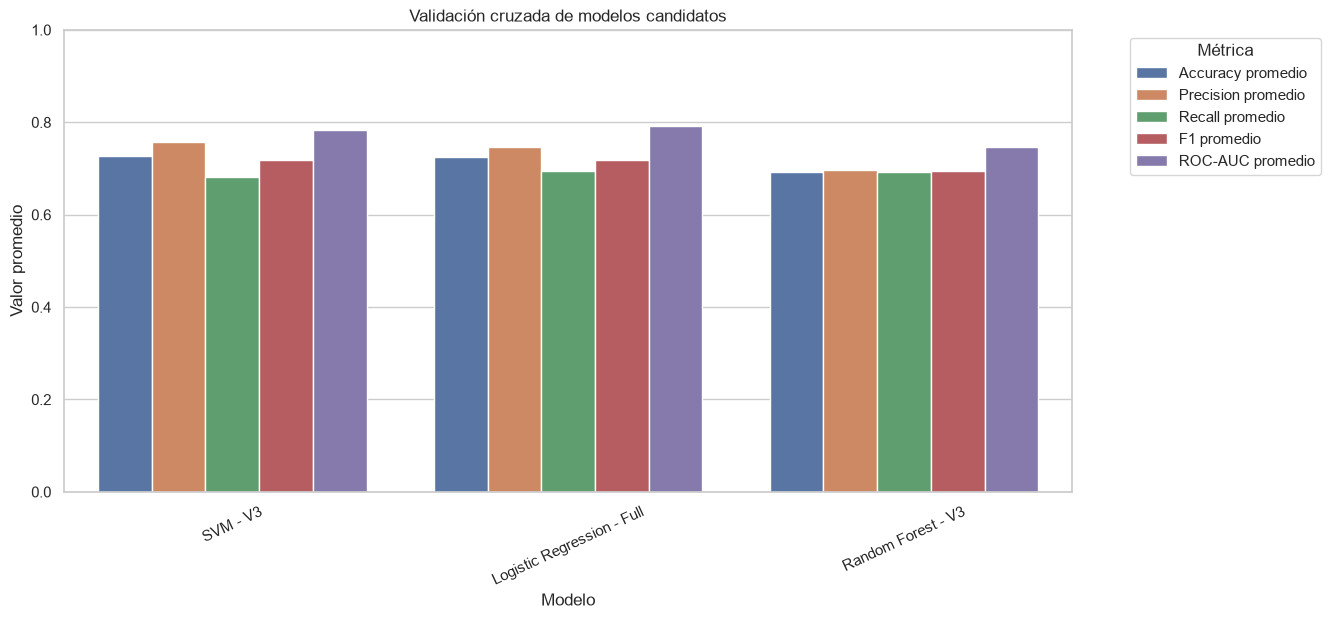

In [48]:
# ============================================================
# GRÁFICA DE VALIDACIÓN CRUZADA
# ============================================================

resultados_cv_melted = resultados_cv_df.melt(
    id_vars="Modelo",
    value_vars=[
        "Accuracy promedio",
        "Precision promedio",
        "Recall promedio",
        "F1 promedio",
        "ROC-AUC promedio"
    ],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=resultados_cv_melted,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Validación cruzada de modelos candidatos")
plt.xlabel("Modelo")
plt.ylabel("Valor promedio")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Optimización SVM

In [51]:
# ============================================================
# OPTIMIZACIÓN SVM - DATASET V3
# Objetivo: maximizar Accuracy
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

param_grid_svm = {
    "model__C": [0.1, 0.5, 1, 2, 5, 10, 20],
    "model__kernel": ["rbf"],
    "model__gamma": ["scale", "auto", 0.001, 0.005, 0.01, 0.05, 0.1],
    "model__class_weight": [None]
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train_v3, y_train_v3)

print("Mejores parámetros SVM:")
print(grid_svm.best_params_)

print("\nMejor accuracy promedio en validación cruzada:")
print(grid_svm.best_score_)

Fitting 5 folds for each of 49 candidates, totalling 245 fits


KeyboardInterrupt: 

In [ ]:
# ============================================================
# EVALUACIÓN SVM OPTIMIZADO
# ============================================================

svm_opt = grid_svm.best_estimator_

y_pred_svm = svm_opt.predict(X_test_v3)
y_proba_svm = svm_opt.predict_proba(X_test_v3)[:, 1]

resultado_svm_opt = {
    "Modelo": "SVM Optimizado - V3",
    "Accuracy": accuracy_score(y_test_v3, y_pred_svm),
    "Precision": precision_score(y_test_v3, y_pred_svm),
    "Recall": recall_score(y_test_v3, y_pred_svm),
    "F1-score": f1_score(y_test_v3, y_pred_svm),
    "ROC-AUC": roc_auc_score(y_test_v3, y_proba_svm)
}

print("SVM Optimizado - V3")
print("Accuracy:", resultado_svm_opt["Accuracy"])
print("Precision:", resultado_svm_opt["Precision"])
print("Recall:", resultado_svm_opt["Recall"])
print("F1-score:", resultado_svm_opt["F1-score"])
print("ROC-AUC:", resultado_svm_opt["ROC-AUC"])

print("\nReporte de clasificación:")
print(classification_report(y_test_v3, y_pred_svm))

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN - SVM OPTIMIZADO
# ============================================================

cm_svm = confusion_matrix(y_test_v3, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No cardio", "Cardio"],
    yticklabels=["No cardio", "Cardio"]
)

plt.title("Matriz de confusión - SVM Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [50]:
# ============================================================
# AJUSTE DE THRESHOLD - SVM
# Objetivo: maximizar Accuracy
# ============================================================

thresholds = np.arange(0.30, 0.71, 0.01)

resultados_threshold_svm = []

for threshold in thresholds:
    y_pred_temp = (y_proba_svm >= threshold).astype(int)

    resultados_threshold_svm.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_v3, y_pred_temp),
        "Precision": precision_score(y_test_v3, y_pred_temp),
        "Recall": recall_score(y_test_v3, y_pred_temp),
        "F1-score": f1_score(y_test_v3, y_pred_temp)
    })

threshold_svm_df = pd.DataFrame(resultados_threshold_svm)

threshold_svm_df = threshold_svm_df.sort_values(
    by="Accuracy",
    ascending=False
)

threshold_svm_df.head(10)

NameError: name 'y_proba_svm' is not defined

NO SE EVALUE SVM PQ ERA MUY PESADO

In [52]:
# ============================================================
# OPTIMIZACIÓN LOGISTIC REGRESSION - DATASET FULL
# Objetivo: maximizar Accuracy
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid_lr = [
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
        "model__class_weight": [None]
    },
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
        "model__class_weight": [None]
    }
]

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(X_train_full, y_train_full)

print("Mejores parámetros Logistic Regression:")
print(grid_lr.best_params_)

print("\nMejor accuracy promedio en validación cruzada:")
print(grid_lr.best_score_)

Fitting 5 folds for each of 39 candidates, totalling 195 fits


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros Logistic Regression:
{'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Mejor accuracy promedio en validación cruzada:
0.7265384247296393


In [53]:
# ============================================================
# EVALUACIÓN LOGISTIC REGRESSION OPTIMIZADA
# ============================================================

lr_opt = grid_lr.best_estimator_

y_pred_lr = lr_opt.predict(X_test_full)
y_proba_lr = lr_opt.predict_proba(X_test_full)[:, 1]

resultado_lr_opt = {
    "Modelo": "Logistic Regression Optimizada - Full",
    "Accuracy": accuracy_score(y_test_full, y_pred_lr),
    "Precision": precision_score(y_test_full, y_pred_lr),
    "Recall": recall_score(y_test_full, y_pred_lr),
    "F1-score": f1_score(y_test_full, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test_full, y_proba_lr)
}

print("Logistic Regression Optimizada - Full")
print("Accuracy:", resultado_lr_opt["Accuracy"])
print("Precision:", resultado_lr_opt["Precision"])
print("Recall:", resultado_lr_opt["Recall"])
print("F1-score:", resultado_lr_opt["F1-score"])
print("ROC-AUC:", resultado_lr_opt["ROC-AUC"])

print("\nReporte de clasificación:")
print(classification_report(y_test_full, y_pred_lr))

Logistic Regression Optimizada - Full
Accuracy: 0.7274536824376052
Precision: 0.7507783057512699
Recall: 0.6920404772692946
F1-score: 0.7202137692549513
ROC-AUC: 0.7920901983899445

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      6441
           1       0.75      0.69      0.72      6621

    accuracy                           0.73     13062
   macro avg       0.73      0.73      0.73     13062
weighted avg       0.73      0.73      0.73     13062



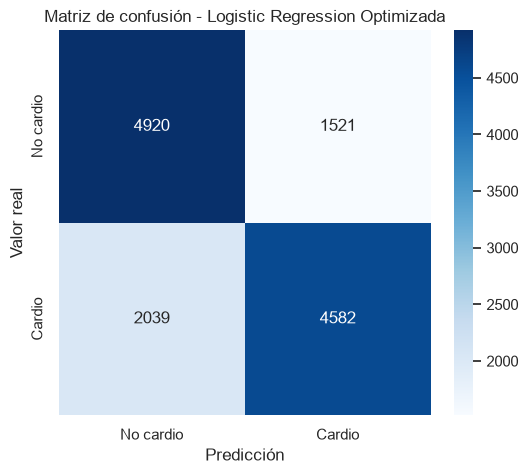

In [54]:
# ============================================================
# MATRIZ DE CONFUSIÓN - LOGISTIC REGRESSION OPTIMIZADA
# ============================================================

cm_lr = confusion_matrix(y_test_full, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No cardio", "Cardio"],
    yticklabels=["No cardio", "Cardio"]
)

plt.title("Matriz de confusión - Logistic Regression Optimizada")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [55]:
# ============================================================
# AJUSTE DE THRESHOLD - LOGISTIC REGRESSION
# Objetivo: maximizar Accuracy
# ============================================================

thresholds = np.arange(0.30, 0.71, 0.01)

resultados_threshold_lr = []

for threshold in thresholds:
    y_pred_temp = (y_proba_lr >= threshold).astype(int)

    resultados_threshold_lr.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_full, y_pred_temp),
        "Precision": precision_score(y_test_full, y_pred_temp),
        "Recall": recall_score(y_test_full, y_pred_temp),
        "F1-score": f1_score(y_test_full, y_pred_temp)
    })

threshold_lr_df = pd.DataFrame(resultados_threshold_lr)

threshold_lr_df = threshold_lr_df.sort_values(
    by="Accuracy",
    ascending=False
)

threshold_lr_df.head(10)

,Threshold,Accuracy,Precision,Recall,F1-score
20,0.50,0.727454,0.750778,0.692040,0.720214
21,0.51,0.726535,0.756520,0.679052,0.715696
19,0.49,0.725999,0.741122,0.706087,0.723180
22,0.52,0.725310,0.761872,0.666365,0.710925
23,0.53,0.724468,0.768574,0.653074,0.706132
18,0.48,0.724315,0.732666,0.718169,0.725345
24,0.54,0.724009,0.775686,0.640840,0.701844
25,0.55,0.723473,0.781900,0.630267,0.697943
17,0.47,0.723166,0.724824,0.731612,0.728202
16,0.46,0.722401,0.717312,0.746564,0.731646


In [56]:
# ============================================================
# MEJOR THRESHOLD LOGISTIC REGRESSION
# ============================================================

best_threshold_lr = threshold_lr_df.iloc[0]["Threshold"]

print("Mejor threshold Logistic Regression:", best_threshold_lr)
print("Mejor accuracy con threshold ajustado:", threshold_lr_df.iloc[0]["Accuracy"])

threshold_lr_df.head(10)

Mejor threshold Logistic Regression: 0.5000000000000002
Mejor accuracy con threshold ajustado: 0.7274536824376052


,Threshold,Accuracy,Precision,Recall,F1-score
20,0.50,0.727454,0.750778,0.692040,0.720214
21,0.51,0.726535,0.756520,0.679052,0.715696
19,0.49,0.725999,0.741122,0.706087,0.723180
22,0.52,0.725310,0.761872,0.666365,0.710925
23,0.53,0.724468,0.768574,0.653074,0.706132
18,0.48,0.724315,0.732666,0.718169,0.725345
24,0.54,0.724009,0.775686,0.640840,0.701844
25,0.55,0.723473,0.781900,0.630267,0.697943
17,0.47,0.723166,0.724824,0.731612,0.728202
16,0.46,0.722401,0.717312,0.746564,0.731646


In [57]:
# ============================================================
# EVALUACIÓN LOGISTIC REGRESSION OPTIMIZADA + THRESHOLD
# ============================================================

y_pred_lr_threshold = (y_proba_lr >= best_threshold_lr).astype(int)

resultado_lr_threshold = {
    "Modelo": "Logistic Regression Optimizada + Threshold - Full",
    "Accuracy": accuracy_score(y_test_full, y_pred_lr_threshold),
    "Precision": precision_score(y_test_full, y_pred_lr_threshold),
    "Recall": recall_score(y_test_full, y_pred_lr_threshold),
    "F1-score": f1_score(y_test_full, y_pred_lr_threshold),
    "ROC-AUC": roc_auc_score(y_test_full, y_proba_lr)
}

print("Logistic Regression Optimizada + Threshold - Full")
print("Accuracy:", resultado_lr_threshold["Accuracy"])
print("Precision:", resultado_lr_threshold["Precision"])
print("Recall:", resultado_lr_threshold["Recall"])
print("F1-score:", resultado_lr_threshold["F1-score"])
print("ROC-AUC:", resultado_lr_threshold["ROC-AUC"])

print("\nReporte de clasificación:")
print(classification_report(y_test_full, y_pred_lr_threshold))

Logistic Regression Optimizada + Threshold - Full
Accuracy: 0.7274536824376052
Precision: 0.7507783057512699
Recall: 0.6920404772692946
F1-score: 0.7202137692549513
ROC-AUC: 0.7920901983899445

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      6441
           1       0.75      0.69      0.72      6621

    accuracy                           0.73     13062
   macro avg       0.73      0.73      0.73     13062
weighted avg       0.73      0.73      0.73     13062



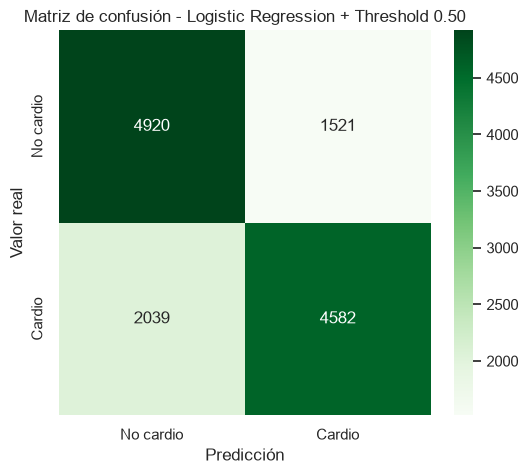

In [58]:
# ============================================================
# MATRIZ DE CONFUSIÓN - LOGISTIC REGRESSION + THRESHOLD
# ============================================================

cm_lr_threshold = confusion_matrix(y_test_full, y_pred_lr_threshold)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_threshold,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No cardio", "Cardio"],
    yticklabels=["No cardio", "Cardio"]
)

plt.title(f"Matriz de confusión - Logistic Regression + Threshold {best_threshold_lr:.2f}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [59]:
# ============================================================
# COMPARACIÓN LOGISTIC OPTIMIZADA VS THRESHOLD
# ============================================================

resultados_lr_final = pd.DataFrame([
    resultado_lr_opt,
    resultado_lr_threshold
])

resultados_lr_final

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression Optimizada - Full,0.727454,0.750778,0.69204,0.720214,0.79209
1,Logistic Regression Optimizada + Threshold - Full,0.727454,0.750778,0.69204,0.720214,0.79209


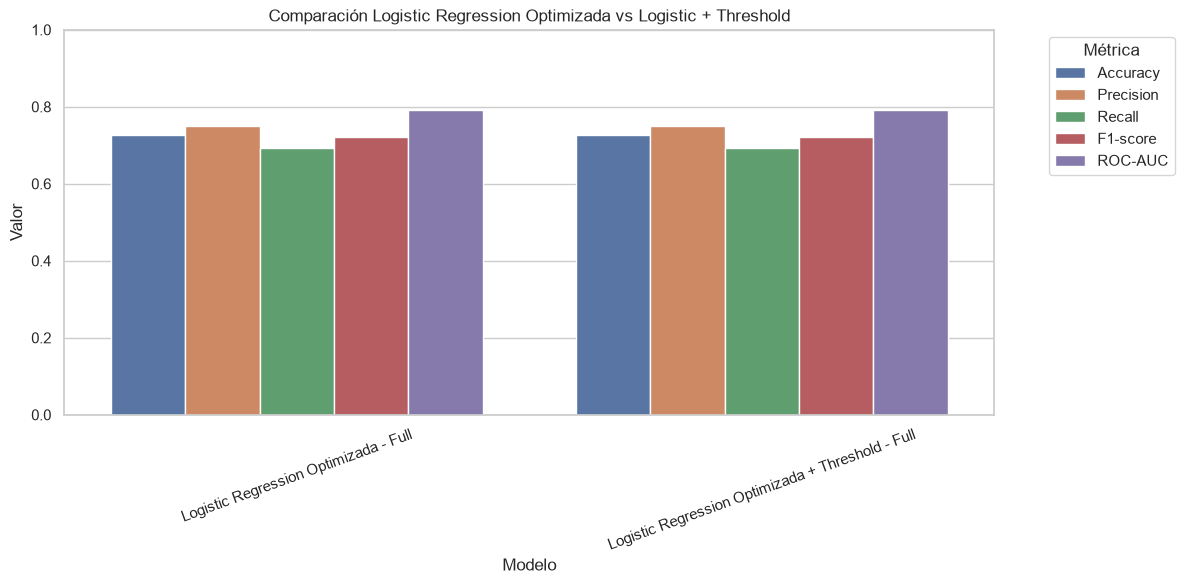

In [60]:
# ============================================================
# GRÁFICA DE COMPARACIÓN - LOGISTIC REGRESSION
# ============================================================

resultados_lr_melted = resultados_lr_final.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resultados_lr_melted,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación Logistic Regression Optimizada vs Logistic + Threshold")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

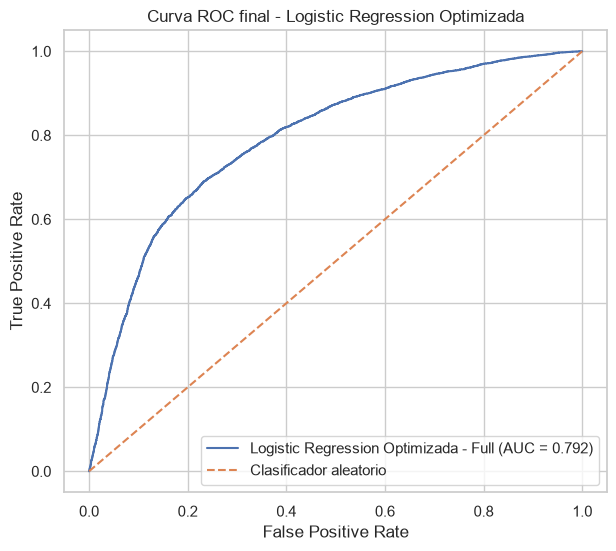

In [61]:
# ============================================================
# CURVA ROC FINAL - LOGISTIC REGRESSION OPTIMIZADA
# ============================================================

fpr_lr, tpr_lr, thresholds_roc_lr = roc_curve(y_test_full, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression Optimizada - Full (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curva ROC final - Logistic Regression Optimizada")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.show()

In [62]:
# ============================================================
# AJUSTE DE THRESHOLD PRIORIZANDO REDUCIR FALSOS NEGATIVOS
# ============================================================

thresholds = np.arange(0.20, 0.51, 0.01)

resultados_threshold_lr_recall = []

for threshold in thresholds:
    y_pred_temp = (y_proba_lr >= threshold).astype(int)
    
    cm = confusion_matrix(y_test_full, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    resultados_threshold_lr_recall.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_full, y_pred_temp),
        "Precision": precision_score(y_test_full, y_pred_temp),
        "Recall": recall_score(y_test_full, y_pred_temp),
        "F1-score": f1_score(y_test_full, y_pred_temp),
        "Falsos positivos": fp,
        "Falsos negativos": fn,
        "Verdaderos positivos": tp,
        "Verdaderos negativos": tn
    })

threshold_lr_recall_df = pd.DataFrame(resultados_threshold_lr_recall)

threshold_lr_recall_df = threshold_lr_recall_df.sort_values(
    by=["Recall", "Accuracy"],
    ascending=[False, False]
)

threshold_lr_recall_df.head(15)

,Threshold,Accuracy,Precision,Recall,F1-score,Falsos positivos,Falsos negativos,Verdaderos positivos,Verdaderos negativos
0,0.20,0.586434,0.552340,0.971454,0.704259,5213,189,6432,1228
1,0.21,0.593094,0.556704,0.968283,0.706953,5105,210,6411,1336
2,0.22,0.598530,0.560602,0.961939,0.708375,4992,252,6369,1449
3,0.23,0.605727,0.565664,0.956955,0.711031,4865,285,6336,1576
4,0.24,0.613382,0.571092,0.953028,0.714205,4739,311,6310,1702
5,0.25,0.620962,0.576704,0.948195,0.717199,4608,343,6278,1833
6,0.26,0.628158,0.582138,0.944117,0.720203,4487,370,6251,1954
7,0.27,0.633594,0.586647,0.938227,0.721906,4377,409,6212,2064
8,0.28,0.641020,0.592635,0.933394,0.724969,4248,441,6180,2193
9,0.29,0.647527,0.598419,0.926144,0.727057,4115,489,6132,2326


In [63]:
# ============================================================
# ELEGIR THRESHOLD CON RECALL MÍNIMO DE 0.75
# Y MEJOR ACCURACY POSIBLE
# ============================================================

candidatos_recall_075 = threshold_lr_recall_df[
    threshold_lr_recall_df["Recall"] >= 0.75
].sort_values(by="Accuracy", ascending=False)

candidatos_recall_075.head(10)

,Threshold,Accuracy,Precision,Recall,F1-score,Falsos positivos,Falsos negativos,Verdaderos positivos,Verdaderos negativos
25,0.45,0.721788,0.711634,0.758496,0.734318,2035,1599,5022,4406
24,0.44,0.719415,0.703637,0.771334,0.735932,2151,1514,5107,4290
23,0.43,0.717501,0.696474,0.784625,0.737926,2264,1426,5195,4177
22,0.42,0.714822,0.689083,0.797010,0.739127,2381,1344,5277,4060
21,0.41,0.714439,0.683602,0.812868,0.742652,2491,1239,5382,3950
20,0.40,0.709539,0.675350,0.822232,0.741588,2617,1177,5444,3824
19,0.39,0.705252,0.667513,0.833862,0.741472,2750,1100,5521,3691
18,0.38,0.700582,0.659901,0.844585,0.740908,2882,1029,5592,3559
17,0.37,0.696754,0.653367,0.855762,0.740993,3006,955,5666,3435
16,0.36,0.693079,0.647271,0.866939,0.741171,3128,881,5740,3313


In [64]:
# ============================================================
# ELEGIR THRESHOLD CON RECALL MÍNIMO DE 0.80
# Y MEJOR ACCURACY POSIBLE
# ============================================================

candidatos_recall_080 = threshold_lr_recall_df[
    threshold_lr_recall_df["Recall"] >= 0.80
].sort_values(by="Accuracy", ascending=False)

candidatos_recall_080.head(10)

,Threshold,Accuracy,Precision,Recall,F1-score,Falsos positivos,Falsos negativos,Verdaderos positivos,Verdaderos negativos
21,0.41,0.714439,0.683602,0.812868,0.742652,2491,1239,5382,3950
20,0.40,0.709539,0.675350,0.822232,0.741588,2617,1177,5444,3824
19,0.39,0.705252,0.667513,0.833862,0.741472,2750,1100,5521,3691
18,0.38,0.700582,0.659901,0.844585,0.740908,2882,1029,5592,3559
17,0.37,0.696754,0.653367,0.855762,0.740993,3006,955,5666,3435
16,0.36,0.693079,0.647271,0.866939,0.741171,3128,881,5740,3313
15,0.35,0.687720,0.640194,0.876605,0.739976,3262,817,5804,3179
14,0.34,0.681519,0.632697,0.886120,0.738266,3406,754,5867,3035
13,0.33,0.675624,0.625791,0.895635,0.736783,3546,691,5930,2895
12,0.32,0.667815,0.617994,0.902583,0.733657,3694,645,5976,2747


In [65]:
# Usar el mejor threshold con recall >= 0.75
best_threshold_lr_recall = candidatos_recall_075.iloc[0]["Threshold"]

print("Threshold elegido:", best_threshold_lr_recall)
print(candidatos_recall_075.iloc[0])

Threshold elegido: 0.45000000000000023
Threshold                  0.450000
Accuracy                   0.721788
Precision                  0.711634
Recall                     0.758496
F1-score                   0.734318
Falsos positivos        2035.000000
Falsos negativos        1599.000000
Verdaderos positivos    5022.000000
Verdaderos negativos    4406.000000
Name: 25, dtype: float64


In [66]:
# ============================================================
# EVALUACIÓN FINAL PRIORIZANDO MENOS FALSOS NEGATIVOS
# ============================================================

y_pred_lr_recall = (y_proba_lr >= best_threshold_lr_recall).astype(int)

resultado_lr_recall = {
    "Modelo": "Logistic Regression + Threshold Recall",
    "Accuracy": accuracy_score(y_test_full, y_pred_lr_recall),
    "Precision": precision_score(y_test_full, y_pred_lr_recall),
    "Recall": recall_score(y_test_full, y_pred_lr_recall),
    "F1-score": f1_score(y_test_full, y_pred_lr_recall),
    "ROC-AUC": roc_auc_score(y_test_full, y_proba_lr)
}

print("Logistic Regression + Threshold priorizando Recall")
print("Threshold:", best_threshold_lr_recall)
print("Accuracy:", resultado_lr_recall["Accuracy"])
print("Precision:", resultado_lr_recall["Precision"])
print("Recall:", resultado_lr_recall["Recall"])
print("F1-score:", resultado_lr_recall["F1-score"])
print("ROC-AUC:", resultado_lr_recall["ROC-AUC"])

print("\nReporte de clasificación:")
print(classification_report(y_test_full, y_pred_lr_recall))

Logistic Regression + Threshold priorizando Recall
Threshold: 0.45000000000000023
Accuracy: 0.7217883938141173
Precision: 0.711633838741675
Recall: 0.7584956955142728
F1-score: 0.7343178827313934
ROC-AUC: 0.7920901983899445

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.73      0.68      0.71      6441
           1       0.71      0.76      0.73      6621

    accuracy                           0.72     13062
   macro avg       0.72      0.72      0.72     13062
weighted avg       0.72      0.72      0.72     13062



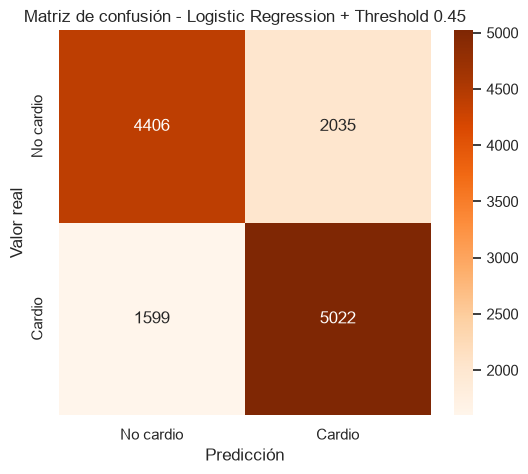

In [67]:
# ============================================================
# MATRIZ DE CONFUSIÓN - THRESHOLD PRIORIZANDO RECALL
# ============================================================

cm_lr_recall = confusion_matrix(y_test_full, y_pred_lr_recall)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_recall,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No cardio", "Cardio"],
    yticklabels=["No cardio", "Cardio"]
)

plt.title(f"Matriz de confusión - Logistic Regression + Threshold {best_threshold_lr_recall:.2f}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [68]:
# ============================================================
# COMPARACIÓN FINAL: NORMAL, ACCURACY, RECALL
# ============================================================

resultados_lr_comparacion = pd.DataFrame([
    resultado_lr_opt,
    resultado_lr_threshold,
    resultado_lr_recall
])

resultados_lr_comparacion

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression Optimizada - Full,0.727454,0.750778,0.692040,0.720214,0.79209
1,Logistic Regression Optimizada + Threshold - Full,0.727454,0.750778,0.692040,0.720214,0.79209
2,Logistic Regression + Threshold Recall,0.721788,0.711634,0.758496,0.734318,0.79209


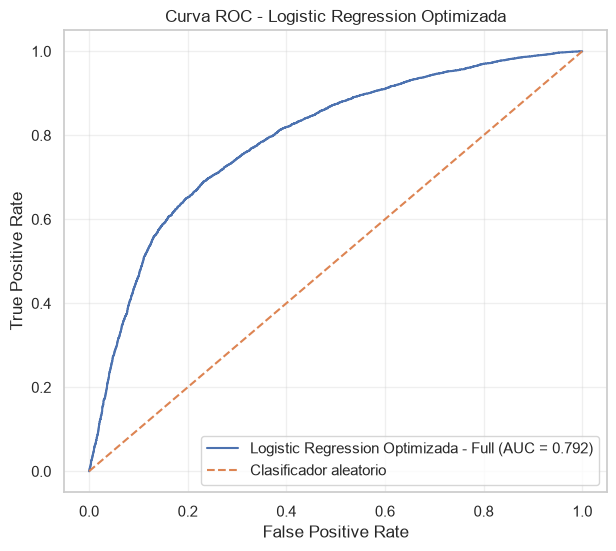

ROC-AUC: 0.7920901983899445


In [69]:
# ============================================================
# CURVA ROC - LOGISTIC REGRESSION OPTIMIZADA
# ============================================================

from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr_lr, tpr_lr, thresholds_roc_lr = roc_curve(y_test_full, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression Optimizada - Full (AUC = {roc_auc_lr:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curva ROC - Logistic Regression Optimizada")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

print("ROC-AUC:", roc_auc_score(y_test_full, y_proba_lr))